In [518]:
import os

import pandas as pd
from matplotlib import pyplot as plt

In [519]:
MAIN_PATH = "../../data/raw/callisia/"
LEAF_PATH = "Leaf"
POLAR_PATH = "Polar H10"

subjects = ["P01", "P02", "P03", "P04", "P05"]

valid_leaf_data = ["timestamp_ms", "green", "acc_x", "acc_y", "acc_z"]
order_activities = [
    "Supine Rest",
    "Seat Rest",
    "Control Breath",
    "Cognitive Load",
    "Standing",
    "Walking"
]

In [520]:
def load_leaf_data(patient):
    """Load PPG and ACC data for a patient from Leaf device."""
    path = os.path.join(MAIN_PATH, patient, LEAF_PATH)
    data_ppg_acc_df = None

    for file in os.listdir(path):
        if file.endswith(".csv") and "ppg_acc" in file:
            data_ppg_acc_df = pd.read_csv(os.path.join(path, file), usecols=valid_leaf_data)
            data_ppg_acc_df = data_ppg_acc_df.drop_duplicates('timestamp_ms')
            data_ppg_acc_df = data_ppg_acc_df.sort_values('timestamp_ms')
            data_ppg_acc_df = data_ppg_acc_df.set_index('timestamp_ms', drop=True)

    return data_ppg_acc_df

In [521]:
def load_hr_polar_activity_data(patient):
    """Load activity data for a patient from Polar H10 device."""
    path = os.path.join(MAIN_PATH, patient, POLAR_PATH)

    hr_list = []

    for activity in order_activities: # iterates in a sorted order the files

        for item in os.listdir(path): # look activity directories inside the POLAR folder
            item_path = os.path.join(path, item)

            # 2. Check if the item is a DIRECTORY and matches the activity name
            if os.path.isdir(item_path) and activity.lower() in item.lower():

                # 3. Look inside this specific activity directory for the CSV
                for inner_file in os.listdir(item_path):
                    if "_HR" in inner_file and inner_file.endswith(".csv"):
                        # Construct the final path to the actual file
                        file_path = os.path.join(item_path, inner_file)

                        temp_df = pd.read_csv(
                            file_path,
                            usecols=["Phone timestamp", "HR [bpm]", "HRV [ms]"],
                        )

                        temp_df["Phone timestamp"] = pd.to_datetime(temp_df["Phone timestamp"])
                        temp_df["Phone timestamp"] = temp_df["Phone timestamp"].dt.tz_localize('Europe/Rome').dt.tz_convert('UTC')
                        temp_df["timestamp_ms"] = temp_df["Phone timestamp"].astype('int64') // 1000

                        temp_df = temp_df.drop(columns=["Phone timestamp"])
                        temp_df = temp_df[["timestamp_ms", "HR [bpm]", "HRV [ms]"]]
                        temp_df = temp_df.sort_values("timestamp_ms")
                        temp_df = temp_df.drop_duplicates("timestamp_ms")
                        temp_df = temp_df.set_index("timestamp_ms", drop=False)


                        # buffer removal
                        if not temp_df.empty:
                            start_time = temp_df.index.min()
                            cutoff_time = start_time + 30000
                            temp_df = temp_df[temp_df.index >= cutoff_time]

                        temp_df = temp_df.rename(columns={
                            "HR [bpm]": "HR"
                        })

                        hr_list.append(temp_df)

    # 5. Concatenate all found DataFrames
    if hr_list:
        hr_values = pd.concat(hr_list, ignore_index=True)

    return hr_values

In [522]:
def load_leaf_polar_data(patient):
    leaf_data = load_leaf_data(subject)
    polar_data = load_hr_polar_activity_data(subject)

    return leaf_data, polar_data

In [523]:
for subject in subjects:
    leaf_df, polar_df = load_leaf_polar_data(subject)

    print("\n" + "="*50)
    print(f"Loaded PPG data for {subject}: \n"
          f"Leaf data shape: {leaf_df.shape} \n"
          f"Polar data shape: {polar_df.shape}")

    row_counts = leaf_df.groupby(leaf_df.index // 1000).size()

    print("--- Hardware Jitter Profile ---")
    print(row_counts.describe())
    print("="*50 + "\n")



Loaded PPG data for P01: 
Leaf data shape: (145866, 4) 
Polar data shape: (2147, 3)
--- Hardware Jitter Profile ---
count    3174.000000
mean       45.956522
std         2.504959
min        18.000000
25%        44.000000
50%        46.000000
75%        48.000000
max        53.000000
dtype: float64


Loaded PPG data for P02: 
Leaf data shape: (132890, 4) 
Polar data shape: (2116, 3)
--- Hardware Jitter Profile ---
count    2884.000000
mean       46.078363
std         4.072287
min         1.000000
25%        45.000000
50%        47.000000
75%        48.000000
max        56.000000
dtype: float64


Loaded PPG data for P03: 
Leaf data shape: (124649, 4) 
Polar data shape: (1210, 3)
--- Hardware Jitter Profile ---
count    2695.000000
mean       46.251948
std         2.545352
min        29.000000
25%        45.000000
50%        46.000000
75%        48.000000
max        55.000000
dtype: float64


Loaded PPG data for P04: 
Leaf data shape: (122147, 4) 
Polar data shape: (2133, 3)
--- Hardware

As a mean, the Leaf device has a sampling rate of 45 Hz. However, since the sampling rate is not stable, we drop it to 40 Hz.

In [524]:
RESAMPLE_RATE = "25ms" # 1000 ms / 40 Hz = 25 ms per row

In [525]:
for subject in subjects:
    leaf_df, _ = load_leaf_polar_data(subject)

    leaf_df['abs_sec'] = leaf_df.index // 1000

    print(f"\n[{subject}] Applying Linear Interpolation to fix hardware jitter...")

    # 1. Convert index to datetime format required by pandas .resample()
    leaf_df.index = pd.to_datetime(leaf_df.index, unit='ms')

    # 2. Snap to the strict 25ms grid (averaging any exact millisecond collisions)
    leaf_resampled = leaf_df.resample(RESAMPLE_RATE).mean()

    # 3. Draw the mathematical bridge across missing data!
    # limit=40 prevents it from faking data over massive hardware dropouts (> 1 second)
    leaf_df = leaf_resampled.interpolate(method='linear', limit=40)

    leaf_df.index = leaf_df.index.astype('int64')

    # 5. Drop any massive gaps that were too large to safely interpolate
    leaf_df = leaf_df.dropna()

    print(f"[{subject}] Data is now locked to exactly 40 Hz. Proceeding to windowing...")



[P01] Applying Linear Interpolation to fix hardware jitter...
[P01] Data is now locked to exactly 40Hz. Proceeding to windowing...

[P02] Applying Linear Interpolation to fix hardware jitter...
[P02] Data is now locked to exactly 40Hz. Proceeding to windowing...

[P03] Applying Linear Interpolation to fix hardware jitter...
[P03] Data is now locked to exactly 40Hz. Proceeding to windowing...

[P04] Applying Linear Interpolation to fix hardware jitter...
[P04] Data is now locked to exactly 40Hz. Proceeding to windowing...

[P05] Applying Linear Interpolation to fix hardware jitter...
[P05] Data is now locked to exactly 40Hz. Proceeding to windowing...


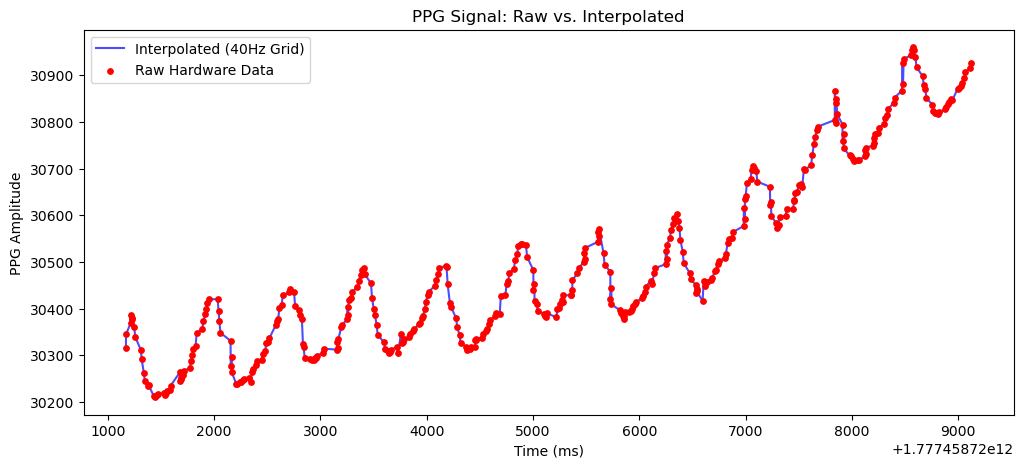

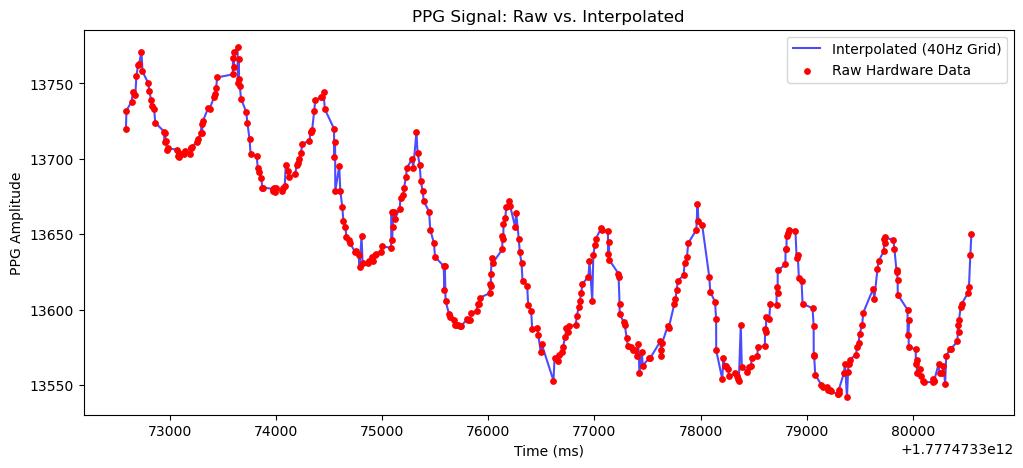

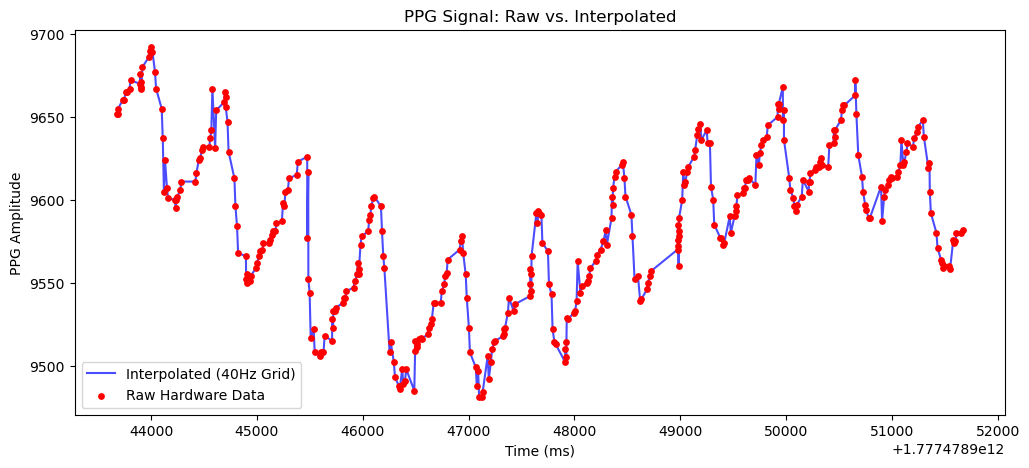

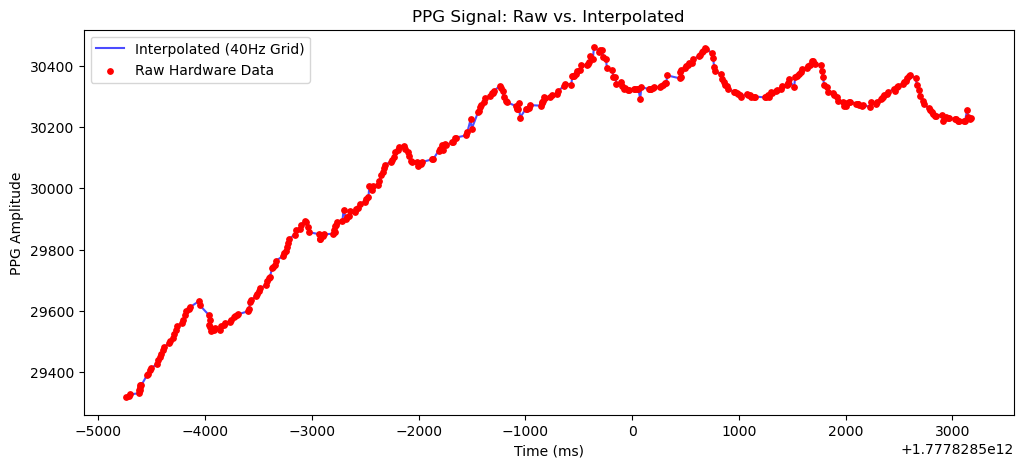

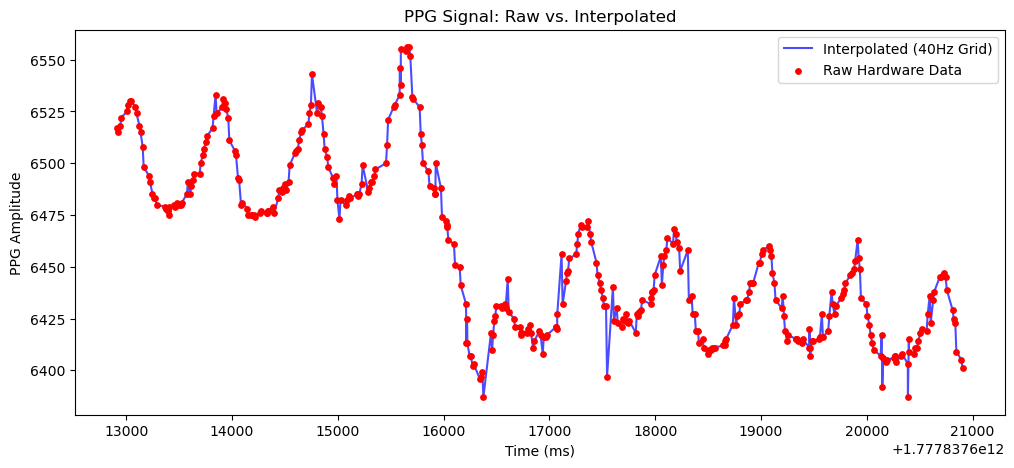

In [526]:
for subject in subjects:
    raw_leaf_df, _ = load_leaf_polar_data(subject)
    leaf_df = pd.read_csv(os.path.join(f"leaf_data_{subject}.csv"), index_col=0)

    # Grab a random 8-second window to inspect
    start_inspect = leaf_df.index[5000]
    end_inspect = start_inspect + 8000

    # 1. The Raw Data (Before Resampling)
    # Assuming you kept a copy of the original raw dataframe named 'raw_leaf_df'
    raw_window = raw_leaf_df[(raw_leaf_df.index >= start_inspect) & (raw_leaf_df.index < end_inspect)]

    # 2. The Interpolated Data (After our pipeline)
    interp_window = leaf_df[(leaf_df.index >= start_inspect) & (leaf_df.index < end_inspect)]

    plt.figure(figsize=(12, 5))

    # Plot the interpolated data as a continuous line
    plt.plot(interp_window.index, interp_window['green'], label='Interpolated (40Hz Grid)', color='blue', alpha=0.7)

    # Plot the raw data as distinct dots on top
    plt.scatter(raw_window.index, raw_window['green'], label='Raw Hardware Data', color='red', s=15, zorder=5)

    plt.title("PPG Signal: Raw vs. Interpolated")
    plt.xlabel("Time (ms)")
    plt.ylabel("PPG Amplitude")
    plt.legend()
    plt.show()

In [527]:
LEAF_TARGET_HZ = 40
window_size_ms = 8000
step_size_ms = 2000


EXPECTED_LEAF_ROWS = int((window_size_ms / 1000) * 40) # Exactly 320 rows

In [531]:
def load_resampled_leaf_data(subject):
    return pd.read_csv(os.path.join(f"resampled_leaf_data_{subject}.csv"), index_col=0)

In [532]:
def load_clean_polar_data(subject):
    return pd.read_csv(os.path.join(f"polar_data_{subject}.csv"), index_col=0)

In [544]:
for subject in subjects:
    leaf_resampled_df = load_resampled_leaf_data(subject)
    polar_df = load_clean_polar_data(subject)

    if leaf_resampled_df.empty or polar_df.empty:
        print(f"Warning: Missing data for {subject}. Skipping synchronization.")
        continue

    feature_windows = []
    label_windows = []
    window_counter = 0

    start_time = max(leaf_resampled_df.index.min(), polar_df.index.min())
    end_time = min(leaf_resampled_df.index.max(), polar_df.index.max())

    for current_time in range(start_time, end_time - window_size_ms + 1, step_size_ms):

        polar_chunk = polar_df[(polar_df.index >= current_time) & (polar_df.index < current_time + window_size_ms)]
        leaf_chunk = leaf_resampled_df[(leaf_resampled_df.index >= current_time) & (leaf_resampled_df.index < current_time + window_size_ms)]

        # Synchronization Safety Checks
        if polar_chunk.empty:
            continue

        if len(leaf_chunk) < EXPECTED_LEAF_ROWS:
            continue

        window_hr_label = round(polar_chunk['HR'].mean(), 4)
        window_hrv_label = round(polar_chunk['HRV [ms]'].mean(), 4)

        new_dict = {
            'window_id': window_counter,
            'HR': window_hr_label,
            'HRV': window_hrv_label
        }

        label_windows.append(new_dict)

        print(f"Window {window_counter}: Time {current_time} to {current_time + window_size_ms} ms - "
              f"Polar rows: {len(polar_chunk)}, Leaf rows: {len(leaf_chunk)},"
              f"HR value: {new_dict['HR']}, HRV Value: {new_dict['HRV']}")

        leaf_chunk = leaf_chunk.iloc[:EXPECTED_LEAF_ROWS]
        leaf_chunk['window_id'] = window_counter
        leaf_chunk = leaf_chunk.reset_index(drop=True)

        feature_windows.append(leaf_chunk)

        window_counter += 1

    # --- 5. FINALIZE AND EXPORT FOR THIS SUBJECT ---
    if label_windows:
        final_features_df = pd.concat(feature_windows, ignore_index=True)
        final_labels_df = pd.DataFrame(label_windows)

        final_features_df = final_features_df[['window_id', 'green', 'acc_x', 'acc_y', 'acc_z']].rename(columns={
            'window_id': 'window_id',
            'green': 'ppg',
            'acc_x': 'acc_x',
            'acc_y': 'acc_y',
            'acc_z': 'acc_z'
        })

        os.makedirs(f"processed/{subject}", exist_ok=True)

        # Dynamically name the file using the subject variable!
        features_filename = f"processed/{subject}/features.csv"
        output_filename = f"processed/{subject}/labels.csv"
        final_labels_df.to_csv(output_filename, index=False)
        final_features_df.to_csv(features_filename, index=False)

        print(f"[{subject}] Success! Saved {window_counter} labels to {output_filename}")
    else:
        print(f"[{subject}] Failed: No valid synchronized windows found.")

Window 0: Time 1777458647252 to 1777458655252 ms - Polar rows: 8, Leaf rows: 320,HR value: 82.25, HRV Value: 7.225
Window 1: Time 1777458649252 to 1777458657252 ms - Polar rows: 7, Leaf rows: 320,HR value: 82.5714, HRV Value: 7.3143
Window 2: Time 1777458651252 to 1777458659252 ms - Polar rows: 8, Leaf rows: 320,HR value: 82.75, HRV Value: 7.225
Window 3: Time 1777458653252 to 1777458661252 ms - Polar rows: 8, Leaf rows: 320,HR value: 82.875, HRV Value: 7.1375
Window 4: Time 1777458655252 to 1777458663252 ms - Polar rows: 8, Leaf rows: 320,HR value: 82.625, HRV Value: 6.95
Window 5: Time 1777458657252 to 1777458665252 ms - Polar rows: 8, Leaf rows: 320,HR value: 82.375, HRV Value: 6.725
Window 6: Time 1777458659252 to 1777458667252 ms - Polar rows: 8, Leaf rows: 320,HR value: 82.125, HRV Value: 6.65
Window 7: Time 1777458661252 to 1777458669252 ms - Polar rows: 8, Leaf rows: 320,HR value: 82.0, HRV Value: 6.6
Window 8: Time 1777458663252 to 1777458671252 ms - Polar rows: 9, Leaf rows: 